In [1]:
pip install opensignalsreader

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.9/55.9 kB 860.7 kB/s eta 0:00:00


Frecuencia cardíaca media: 74.6 bpm


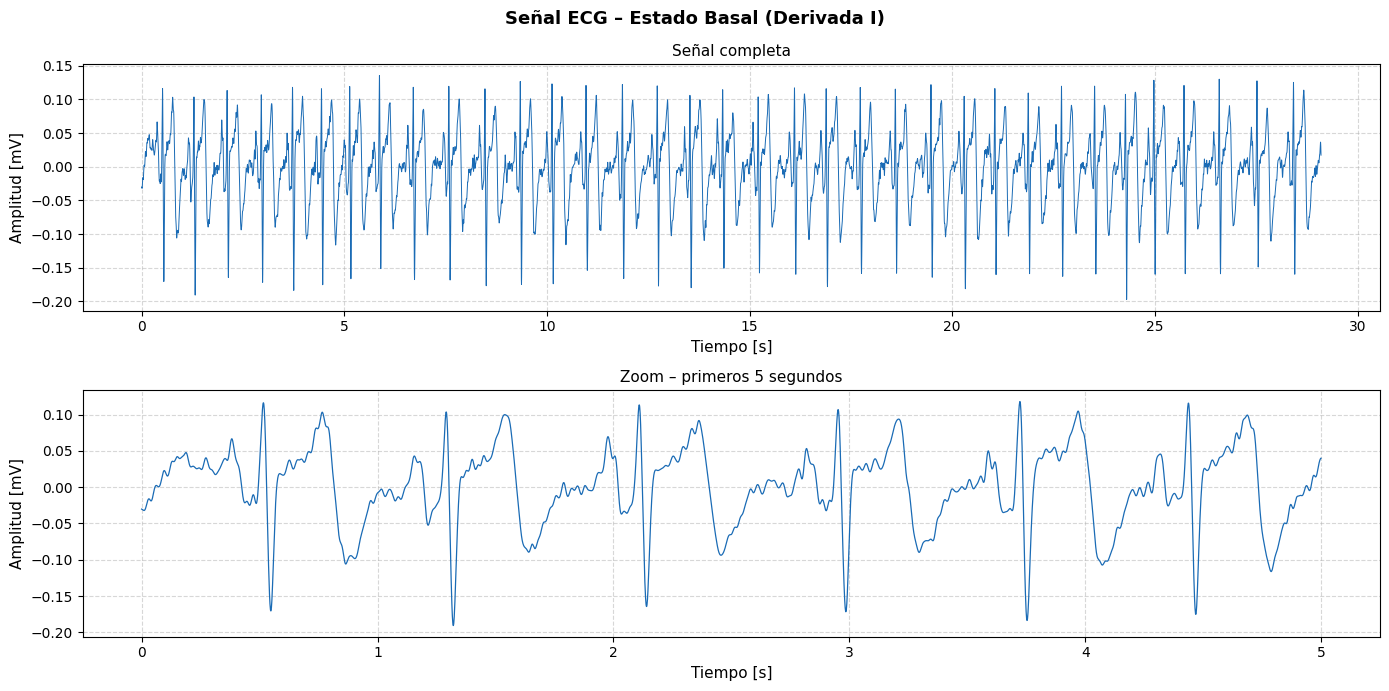

In [40]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, iirnotch, find_peaks
from opensignalsreader import OpenSignalsReader

# ── Lectura ───────────────────────────────────────────────────────────────────
acq = OpenSignalsReader('señal_basal_l5.txt')
fs  = acq.sampling_rate

ecg = acq.signal()['ECG'].astype(float)
ecg -= ecg.mean()

t = np.arange(len(ecg)) / fs

# ── Filtros ───────────────────────────────────────────────────────────────────
def bandpass(sig, low, high, fs, order=4):
    b, a = butter(order, [low/(0.5*fs), high/(0.5*fs)], btype='band')
    return filtfilt(b, a, sig)

ecg = bandpass(ecg, 0.5, 40, fs)
b_n, a_n = iirnotch(60, 30, fs)
ecg = filtfilt(b_n, a_n, ecg)

# ── Detección de picos R y FC ─────────────────────────────────────────────────
peaks, _ = find_peaks(ecg, distance=int(0.4*fs), height=0.4*ecg.max())
rr_ms    = np.diff(peaks) / fs * 1000
fc_media = (60 / (rr_ms / 1000)).mean()

print(f"Frecuencia cardíaca media: {fc_media:.1f} bpm")

# ── Graficar señal completa ───────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 7))
fig.suptitle("Señal ECG – Estado Basal (Derivada I)", fontsize=13, fontweight='bold')

# Señal completa
ax1.plot(t, ecg, color='#1a6bb5', lw=0.7)
ax1.set_title("Señal completa", fontsize=11)
ax1.set_xlabel("Tiempo [s]", fontsize=11)
ax1.set_ylabel("Amplitud [mV]", fontsize=11)
ax1.grid(True, linestyle='--', alpha=0.5)

# Zoom 5 segundos
samples = 5 * fs
ax2.plot(t[:samples], ecg[:samples], color='#1a6bb5', lw=0.9)
ax2.set_title("Zoom – primeros 5 segundos", fontsize=11)
ax2.set_xlabel("Tiempo [s]", fontsize=11)
ax2.set_ylabel("Amplitud [mV]", fontsize=11)
ax2.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()


Frecuencia cardíaca media: 68.0 bpm


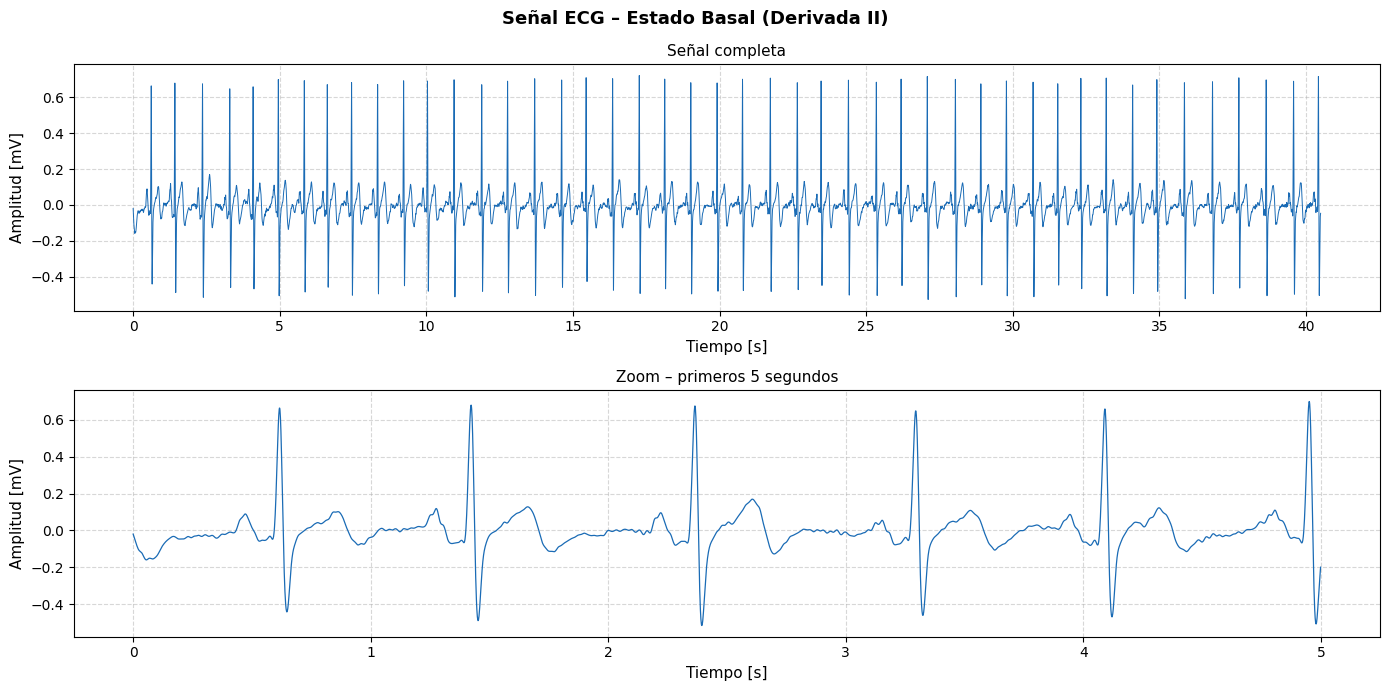

In [41]:


# ── Lectura ───────────────────────────────────────────────────────────────────
acq = OpenSignalsReader('señal_basal_d2_l5.txt')
fs  = acq.sampling_rate

ecg = acq.signal()['ECG'].astype(float)
ecg -= ecg.mean()

t = np.arange(len(ecg)) / fs

# ── Filtros ───────────────────────────────────────────────────────────────────
def bandpass(sig, low, high, fs, order=4):
    b, a = butter(order, [low/(0.5*fs), high/(0.5*fs)], btype='band')
    return filtfilt(b, a, sig)

ecg = bandpass(ecg, 0.5, 40, fs)
b_n, a_n = iirnotch(60, 30, fs)
ecg = filtfilt(b_n, a_n, ecg)

# ── Detección de picos R y FC ─────────────────────────────────────────────────
peaks, _ = find_peaks(ecg, distance=int(0.4*fs), height=0.4*ecg.max())
rr_ms    = np.diff(peaks) / fs * 1000
fc_media = (60 / (rr_ms / 1000)).mean()

print(f"Frecuencia cardíaca media: {fc_media:.1f} bpm")

# ── Graficar señal completa ───────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 7))
fig.suptitle("Señal ECG – Estado Basal (Derivada II)", fontsize=13, fontweight='bold')

# Señal completa
ax1.plot(t, ecg, color='#1a6bb5', lw=0.7)
ax1.set_title("Señal completa", fontsize=11)
ax1.set_xlabel("Tiempo [s]", fontsize=11)
ax1.set_ylabel("Amplitud [mV]", fontsize=11)
ax1.grid(True, linestyle='--', alpha=0.5)

# Zoom 5 segundos
samples = 5 * fs
ax2.plot(t[:samples], ecg[:samples], color='#1a6bb5', lw=0.9)
ax2.set_title("Zoom – primeros 5 segundos", fontsize=11)
ax2.set_xlabel("Tiempo [s]", fontsize=11)
ax2.set_ylabel("Amplitud [mV]", fontsize=11)
ax2.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()


Frecuencia cardíaca media: 71.7 bpm


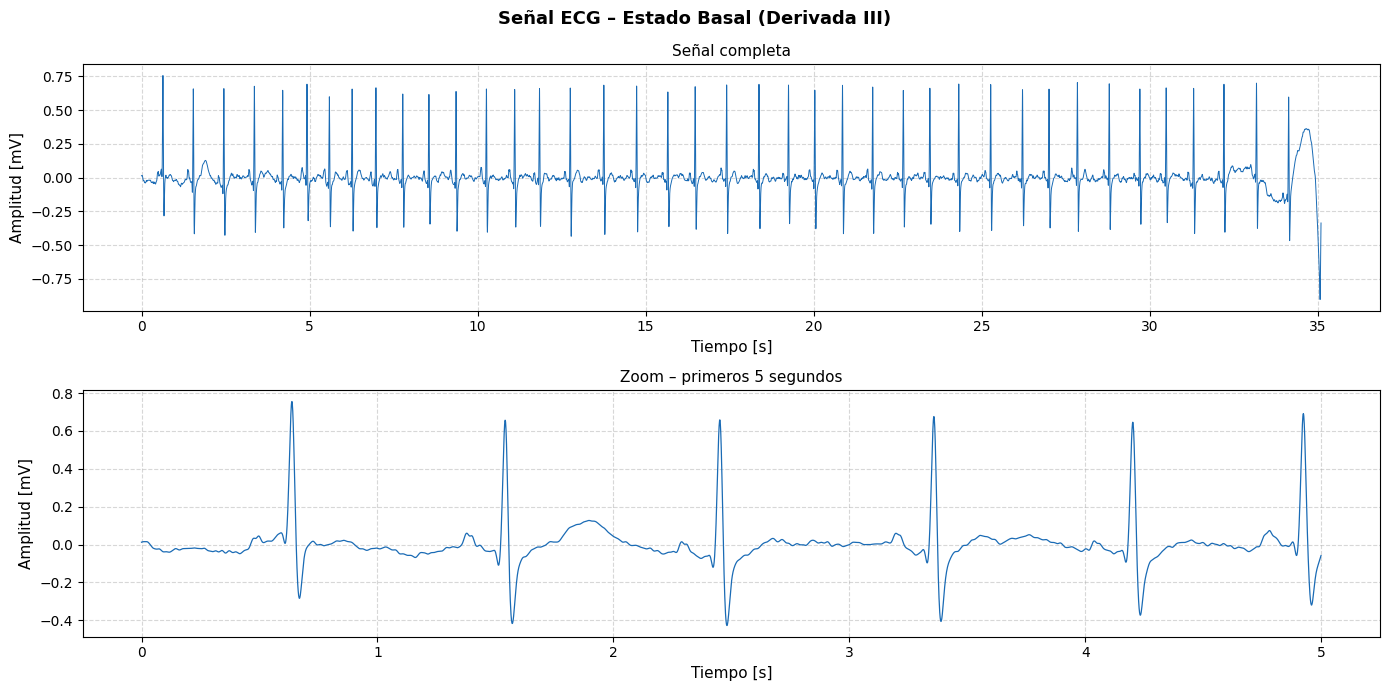

In [42]:


# ── Lectura ───────────────────────────────────────────────────────────────────
acq = OpenSignalsReader('señal_basal_d3_l5.txt')
fs  = acq.sampling_rate

ecg = acq.signal()['ECG'].astype(float)
ecg -= ecg.mean()

t = np.arange(len(ecg)) / fs

# ── Filtros ───────────────────────────────────────────────────────────────────
def bandpass(sig, low, high, fs, order=4):
    b, a = butter(order, [low/(0.5*fs), high/(0.5*fs)], btype='band')
    return filtfilt(b, a, sig)

ecg = bandpass(ecg, 0.5, 40, fs)
b_n, a_n = iirnotch(60, 30, fs)
ecg = filtfilt(b_n, a_n, ecg)

# ── Detección de picos R y FC ─────────────────────────────────────────────────
peaks, _ = find_peaks(ecg, distance=int(0.4*fs), height=0.4*ecg.max())
rr_ms    = np.diff(peaks) / fs * 1000
fc_media = (60 / (rr_ms / 1000)).mean()

print(f"Frecuencia cardíaca media: {fc_media:.1f} bpm")

# ── Graficar señal completa ───────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 7))
fig.suptitle("Señal ECG – Estado Basal (Derivada III)", fontsize=13, fontweight='bold')

# Señal completa
ax1.plot(t, ecg, color='#1a6bb5', lw=0.7)
ax1.set_title("Señal completa", fontsize=11)
ax1.set_xlabel("Tiempo [s]", fontsize=11)
ax1.set_ylabel("Amplitud [mV]", fontsize=11)
ax1.grid(True, linestyle='--', alpha=0.5)

# Zoom 5 segundos
samples = 5 * fs
ax2.plot(t[:samples], ecg[:samples], color='#1a6bb5', lw=0.9)
ax2.set_title("Zoom – primeros 5 segundos", fontsize=11)
ax2.set_xlabel("Tiempo [s]", fontsize=11)
ax2.set_ylabel("Amplitud [mV]", fontsize=11)
ax2.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()


Frecuencia cardíaca media: 69.3 bpm


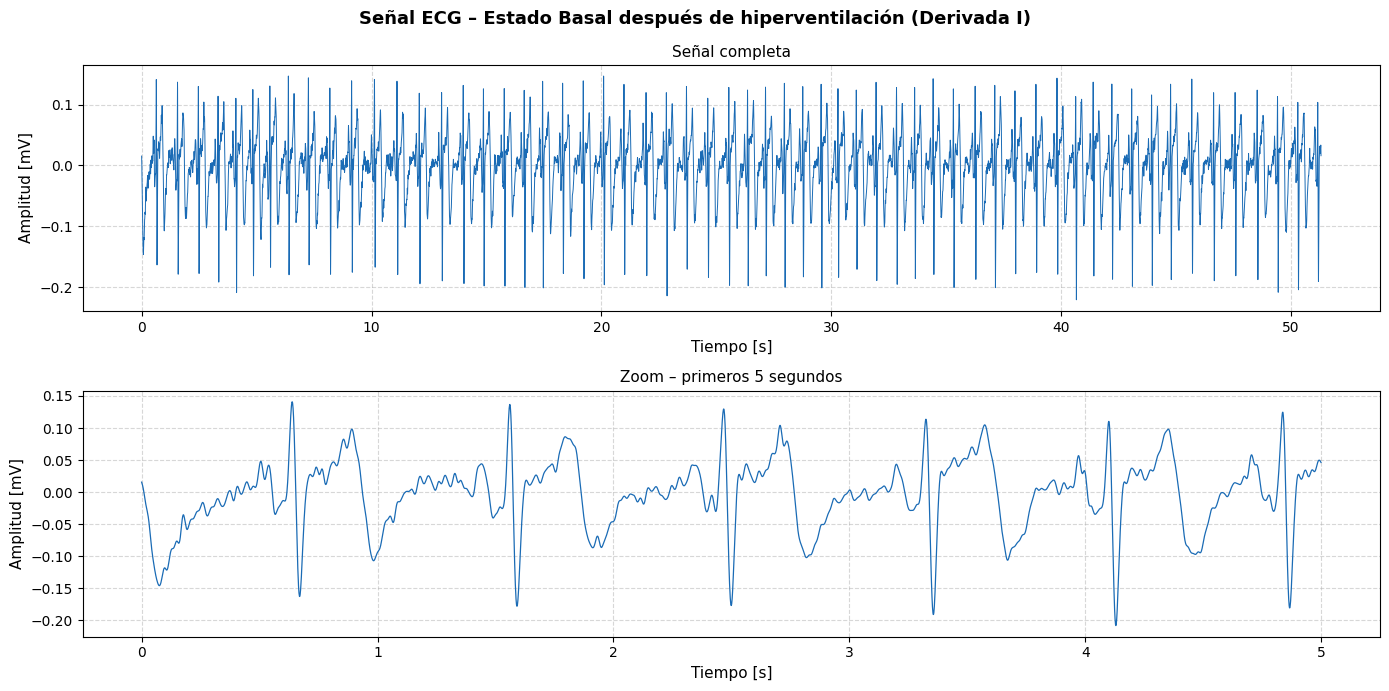

In [43]:


# ── Lectura ───────────────────────────────────────────────────────────────────
acq = OpenSignalsReader('2da_basal_derivada1.txt')
fs  = acq.sampling_rate

ecg = acq.signal()['ECG'].astype(float)
ecg -= ecg.mean()

t = np.arange(len(ecg)) / fs

# ── Filtros ───────────────────────────────────────────────────────────────────
def bandpass(sig, low, high, fs, order=4):
    b, a = butter(order, [low/(0.5*fs), high/(0.5*fs)], btype='band')
    return filtfilt(b, a, sig)

ecg = bandpass(ecg, 0.5, 40, fs)
b_n, a_n = iirnotch(60, 30, fs)
ecg = filtfilt(b_n, a_n, ecg)

# ── Detección de picos R y FC ─────────────────────────────────────────────────
peaks, _ = find_peaks(ecg, distance=int(0.4*fs), height=0.4*ecg.max())
rr_ms    = np.diff(peaks) / fs * 1000
fc_media = (60 / (rr_ms / 1000)).mean()

print(f"Frecuencia cardíaca media: {fc_media:.1f} bpm")

# ── Graficar señal completa ───────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 7))
fig.suptitle("Señal ECG – Estado Basal después de hiperventilación (Derivada I)", fontsize=13, fontweight='bold')

# Señal completa
ax1.plot(t, ecg, color='#1a6bb5', lw=0.7)
ax1.set_title("Señal completa", fontsize=11)
ax1.set_xlabel("Tiempo [s]", fontsize=11)
ax1.set_ylabel("Amplitud [mV]", fontsize=11)
ax1.grid(True, linestyle='--', alpha=0.5)

# Zoom 5 segundos
samples = 5 * fs
ax2.plot(t[:samples], ecg[:samples], color='#1a6bb5', lw=0.9)
ax2.set_title("Zoom – primeros 5 segundos", fontsize=11)
ax2.set_xlabel("Tiempo [s]", fontsize=11)
ax2.set_ylabel("Amplitud [mV]", fontsize=11)
ax2.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()



Frecuencia cardíaca media: 93.6 bpm


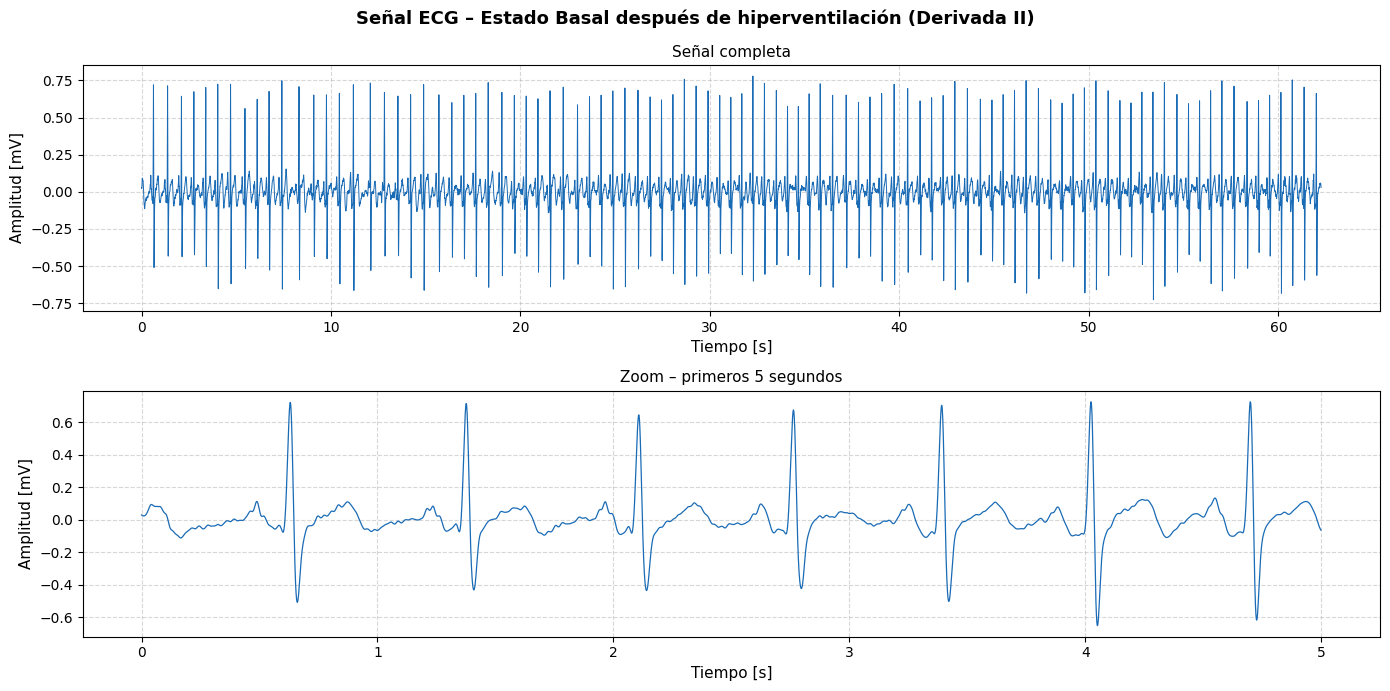

In [44]:

# ── Lectura ───────────────────────────────────────────────────────────────────
acq = OpenSignalsReader('ciclo1_derivada2_intento2.txt')
fs  = acq.sampling_rate

ecg = acq.signal()['ECG'].astype(float)
ecg -= ecg.mean()

t = np.arange(len(ecg)) / fs

# ── Filtros ───────────────────────────────────────────────────────────────────
def bandpass(sig, low, high, fs, order=4):
    b, a = butter(order, [low/(0.5*fs), high/(0.5*fs)], btype='band')
    return filtfilt(b, a, sig)

ecg = bandpass(ecg, 0.5, 40, fs)
b_n, a_n = iirnotch(60, 30, fs)
ecg = filtfilt(b_n, a_n, ecg)

# ── Detección de picos R y FC ─────────────────────────────────────────────────
peaks, _ = find_peaks(ecg, distance=int(0.4*fs), height=0.4*ecg.max())
rr_ms    = np.diff(peaks) / fs * 1000
fc_media = (60 / (rr_ms / 1000)).mean()

print(f"Frecuencia cardíaca media: {fc_media:.1f} bpm")

# ── Graficar señal completa ───────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 7))
fig.suptitle("Señal ECG – Estado Basal después de hiperventilación (Derivada II)", fontsize=13, fontweight='bold')

# Señal completa
ax1.plot(t, ecg, color='#1a6bb5', lw=0.7)
ax1.set_title("Señal completa", fontsize=11)
ax1.set_xlabel("Tiempo [s]", fontsize=11)
ax1.set_ylabel("Amplitud [mV]", fontsize=11)
ax1.grid(True, linestyle='--', alpha=0.5)

# Zoom 5 segundos
samples = 5 * fs
ax2.plot(t[:samples], ecg[:samples], color='#1a6bb5', lw=0.9)
ax2.set_title("Zoom – primeros 5 segundos", fontsize=11)
ax2.set_xlabel("Tiempo [s]", fontsize=11)
ax2.set_ylabel("Amplitud [mV]", fontsize=11)
ax2.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()



Frecuencia cardíaca media: 71.1 bpm


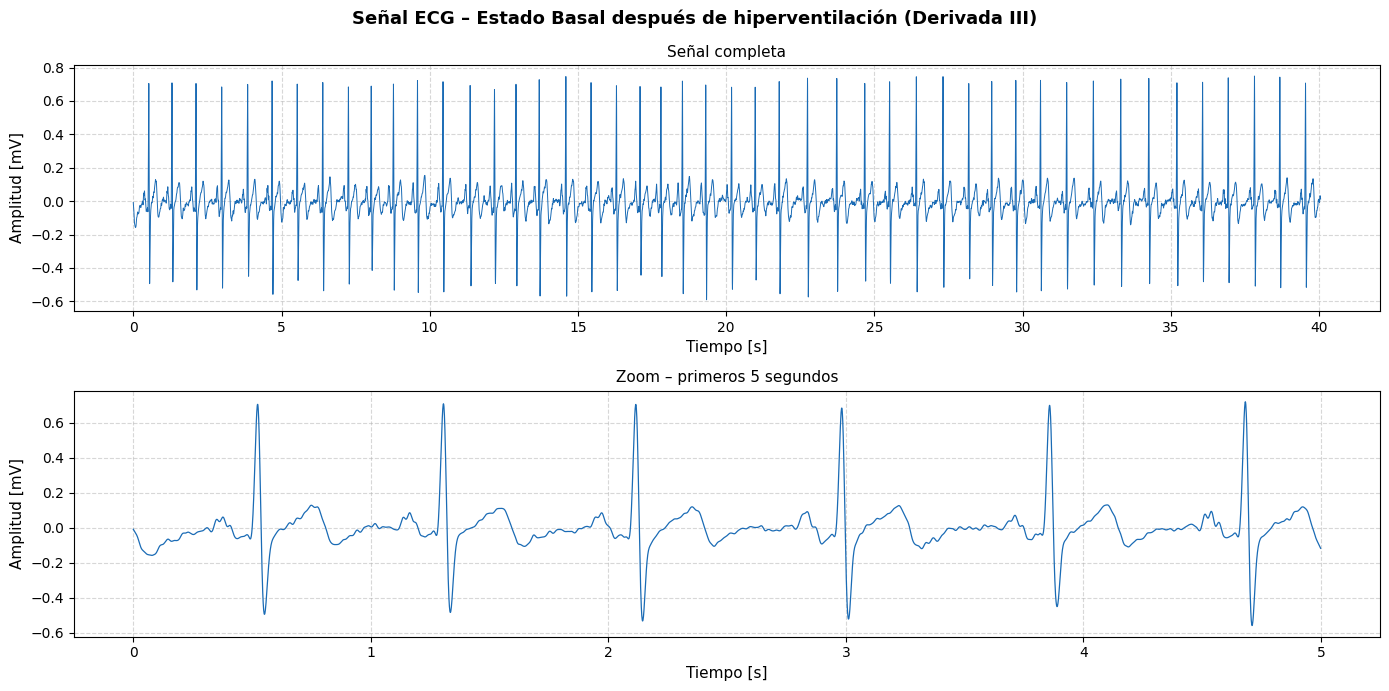

In [45]:


# ── Lectura ───────────────────────────────────────────────────────────────────
acq = OpenSignalsReader('basal_final.txt')
fs  = acq.sampling_rate

ecg = acq.signal()['ECG'].astype(float)
ecg -= ecg.mean()

t = np.arange(len(ecg)) / fs

# ── Filtros ───────────────────────────────────────────────────────────────────
def bandpass(sig, low, high, fs, order=4):
    b, a = butter(order, [low/(0.5*fs), high/(0.5*fs)], btype='band')
    return filtfilt(b, a, sig)

ecg = bandpass(ecg, 0.5, 40, fs)
b_n, a_n = iirnotch(60, 30, fs)
ecg = filtfilt(b_n, a_n, ecg)

# ── Detección de picos R y FC ─────────────────────────────────────────────────
peaks, _ = find_peaks(ecg, distance=int(0.4*fs), height=0.4*ecg.max())
rr_ms    = np.diff(peaks) / fs * 1000
fc_media = (60 / (rr_ms / 1000)).mean()

print(f"Frecuencia cardíaca media: {fc_media:.1f} bpm")

# ── Graficar señal completa ───────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 7))
fig.suptitle("Señal ECG – Estado Basal después de hiperventilación (Derivada III)", fontsize=13, fontweight='bold')

# Señal completa
ax1.plot(t, ecg, color='#1a6bb5', lw=0.7)
ax1.set_title("Señal completa", fontsize=11)
ax1.set_xlabel("Tiempo [s]", fontsize=11)
ax1.set_ylabel("Amplitud [mV]", fontsize=11)
ax1.grid(True, linestyle='--', alpha=0.5)

# Zoom 5 segundos
samples = 5 * fs
ax2.plot(t[:samples], ecg[:samples], color='#1a6bb5', lw=0.9)
ax2.set_title("Zoom – primeros 5 segundos", fontsize=11)
ax2.set_xlabel("Tiempo [s]", fontsize=11)
ax2.set_ylabel("Amplitud [mV]", fontsize=11)
ax2.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()



Frecuencia cardíaca media: 108.1 bpm


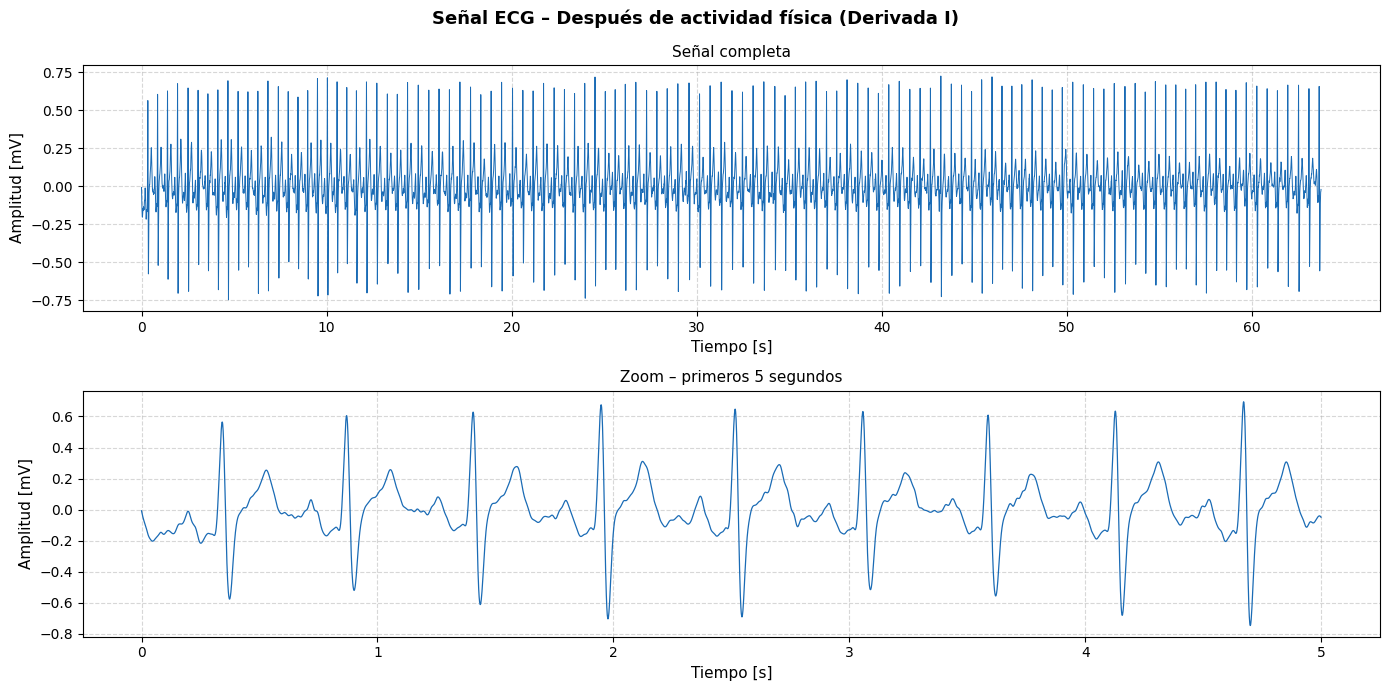

In [46]:
# ── Lectura ───────────────────────────────────────────────────────────────────
acq = OpenSignalsReader('hiperventillacion_derivada1.txt')
fs  = acq.sampling_rate

ecg = acq.signal()['ECG'].astype(float)
ecg -= ecg.mean()

t = np.arange(len(ecg)) / fs

# ── Filtros ───────────────────────────────────────────────────────────────────
def bandpass(sig, low, high, fs, order=4):
    b, a = butter(order, [low/(0.5*fs), high/(0.5*fs)], btype='band')
    return filtfilt(b, a, sig)

ecg = bandpass(ecg, 0.5, 40, fs)
b_n, a_n = iirnotch(60, 30, fs)
ecg = filtfilt(b_n, a_n, ecg)

# ── Detección de picos R y FC ─────────────────────────────────────────────────
peaks, _ = find_peaks(ecg, distance=int(0.4*fs), height=0.4*ecg.max())
rr_ms    = np.diff(peaks) / fs * 1000
fc_media = (60 / (rr_ms / 1000)).mean()

print(f"Frecuencia cardíaca media: {fc_media:.1f} bpm")

# ── Graficar señal completa ───────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 7))
fig.suptitle("Señal ECG – Después de actividad física (Derivada I)", fontsize=13, fontweight='bold')

# Señal completa
ax1.plot(t, ecg, color='#1a6bb5', lw=0.7)
ax1.set_title("Señal completa", fontsize=11)
ax1.set_xlabel("Tiempo [s]", fontsize=11)
ax1.set_ylabel("Amplitud [mV]", fontsize=11)
ax1.grid(True, linestyle='--', alpha=0.5)

# Zoom 5 segundos
samples = 5 * fs
ax2.plot(t[:samples], ecg[:samples], color='#1a6bb5', lw=0.9)
ax2.set_title("Zoom – primeros 5 segundos", fontsize=11)
ax2.set_xlabel("Tiempo [s]", fontsize=11)
ax2.set_ylabel("Amplitud [mV]", fontsize=11)
ax2.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()



Frecuencia cardíaca media: 105.7 bpm


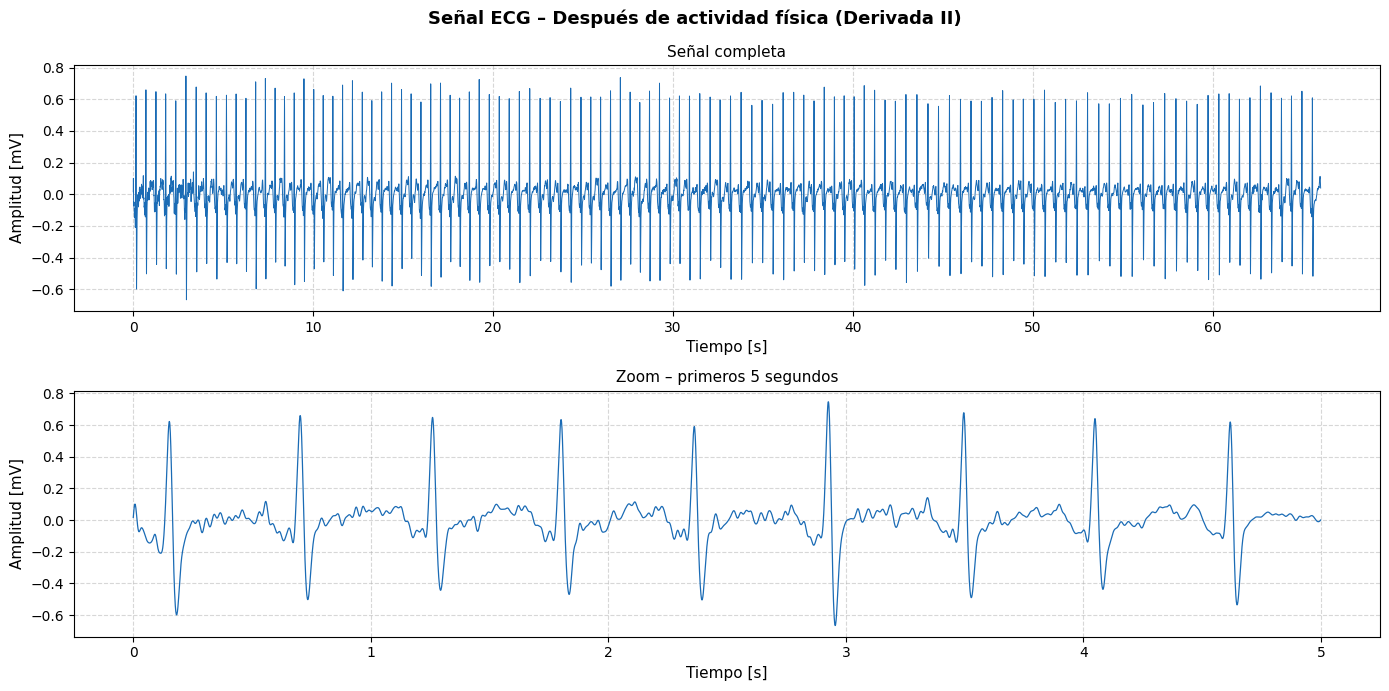

In [48]:
# ── Lectura ───────────────────────────────────────────────────────────────────
acq = OpenSignalsReader('hiperventilacion_derivada2.txt')
fs  = acq.sampling_rate

ecg = acq.signal()['ECG'].astype(float)
ecg -= ecg.mean()

t = np.arange(len(ecg)) / fs

# ── Filtros ───────────────────────────────────────────────────────────────────
def bandpass(sig, low, high, fs, order=4):
    b, a = butter(order, [low/(0.5*fs), high/(0.5*fs)], btype='band')
    return filtfilt(b, a, sig)

ecg = bandpass(ecg, 0.5, 40, fs)
b_n, a_n = iirnotch(60, 30, fs)
ecg = filtfilt(b_n, a_n, ecg)

# ── Detección de picos R y FC ─────────────────────────────────────────────────
peaks, _ = find_peaks(ecg, distance=int(0.4*fs), height=0.4*ecg.max())
rr_ms    = np.diff(peaks) / fs * 1000
fc_media = (60 / (rr_ms / 1000)).mean()

print(f"Frecuencia cardíaca media: {fc_media:.1f} bpm")

# ── Graficar señal completa ───────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 7))
fig.suptitle("Señal ECG – Después de actividad física (Derivada II)", fontsize=13, fontweight='bold')

# Señal completa
ax1.plot(t, ecg, color='#1a6bb5', lw=0.7)
ax1.set_title("Señal completa", fontsize=11)
ax1.set_xlabel("Tiempo [s]", fontsize=11)
ax1.set_ylabel("Amplitud [mV]", fontsize=11)
ax1.grid(True, linestyle='--', alpha=0.5)

# Zoom 5 segundos
samples = 5 * fs
ax2.plot(t[:samples], ecg[:samples], color='#1a6bb5', lw=0.9)
ax2.set_title("Zoom – primeros 5 segundos", fontsize=11)
ax2.set_xlabel("Tiempo [s]", fontsize=11)
ax2.set_ylabel("Amplitud [mV]", fontsize=11)
ax2.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()



Frecuencia cardíaca media: 108.4 bpm


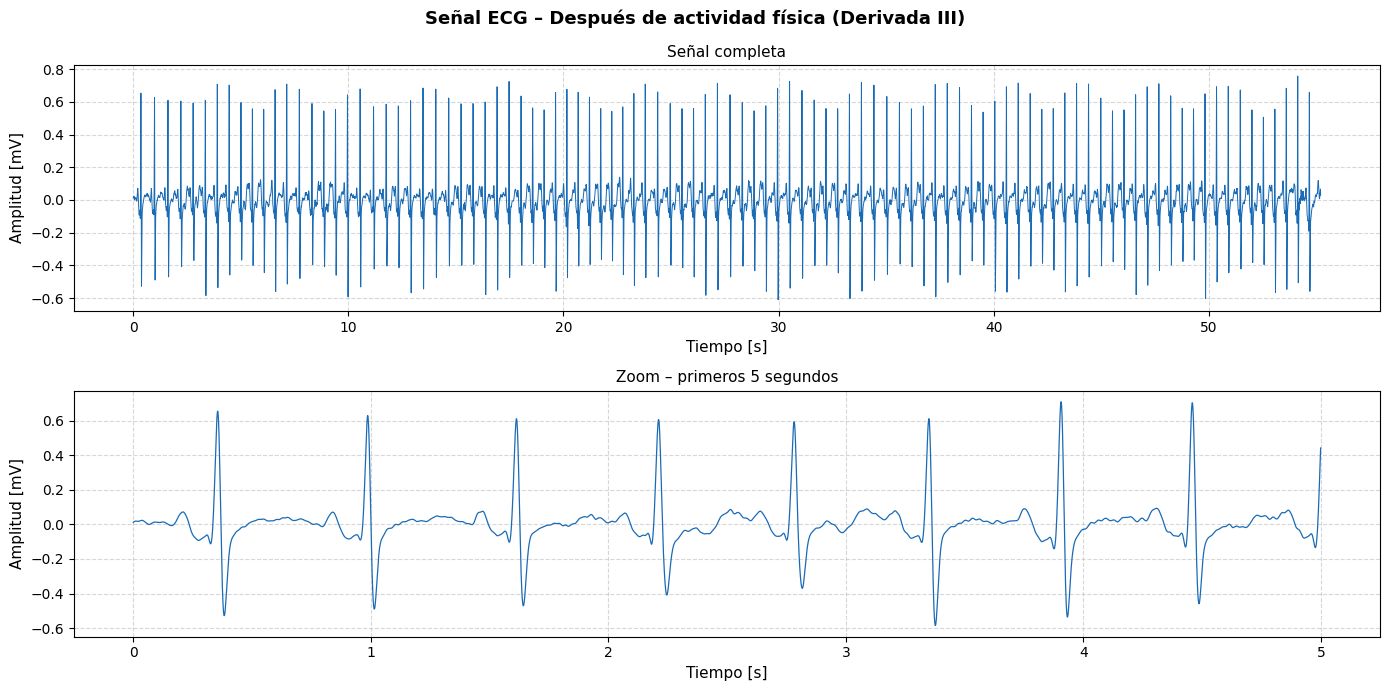

In [49]:
# ── Lectura ───────────────────────────────────────────────────────────────────
acq = OpenSignalsReader('hiperventilacion_derivada3.txt')
fs  = acq.sampling_rate

ecg = acq.signal()['ECG'].astype(float)
ecg -= ecg.mean()

t = np.arange(len(ecg)) / fs

# ── Filtros ───────────────────────────────────────────────────────────────────
def bandpass(sig, low, high, fs, order=4):
    b, a = butter(order, [low/(0.5*fs), high/(0.5*fs)], btype='band')
    return filtfilt(b, a, sig)

ecg = bandpass(ecg, 0.5, 40, fs)
b_n, a_n = iirnotch(60, 30, fs)
ecg = filtfilt(b_n, a_n, ecg)

# ── Detección de picos R y FC ─────────────────────────────────────────────────
peaks, _ = find_peaks(ecg, distance=int(0.4*fs), height=0.4*ecg.max())
rr_ms    = np.diff(peaks) / fs * 1000
fc_media = (60 / (rr_ms / 1000)).mean()

print(f"Frecuencia cardíaca media: {fc_media:.1f} bpm")

# ── Graficar señal completa ───────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 7))
fig.suptitle("Señal ECG – Después de actividad física (Derivada III)", fontsize=13, fontweight='bold')

# Señal completa
ax1.plot(t, ecg, color='#1a6bb5', lw=0.7)
ax1.set_title("Señal completa", fontsize=11)
ax1.set_xlabel("Tiempo [s]", fontsize=11)
ax1.set_ylabel("Amplitud [mV]", fontsize=11)
ax1.grid(True, linestyle='--', alpha=0.5)

# Zoom 5 segundos
samples = 5 * fs
ax2.plot(t[:samples], ecg[:samples], color='#1a6bb5', lw=0.9)
ax2.set_title("Zoom – primeros 5 segundos", fontsize=11)
ax2.set_xlabel("Tiempo [s]", fontsize=11)
ax2.set_ylabel("Amplitud [mV]", fontsize=11)
ax2.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()



Frecuencia cardíaca media: 99.1 bpm


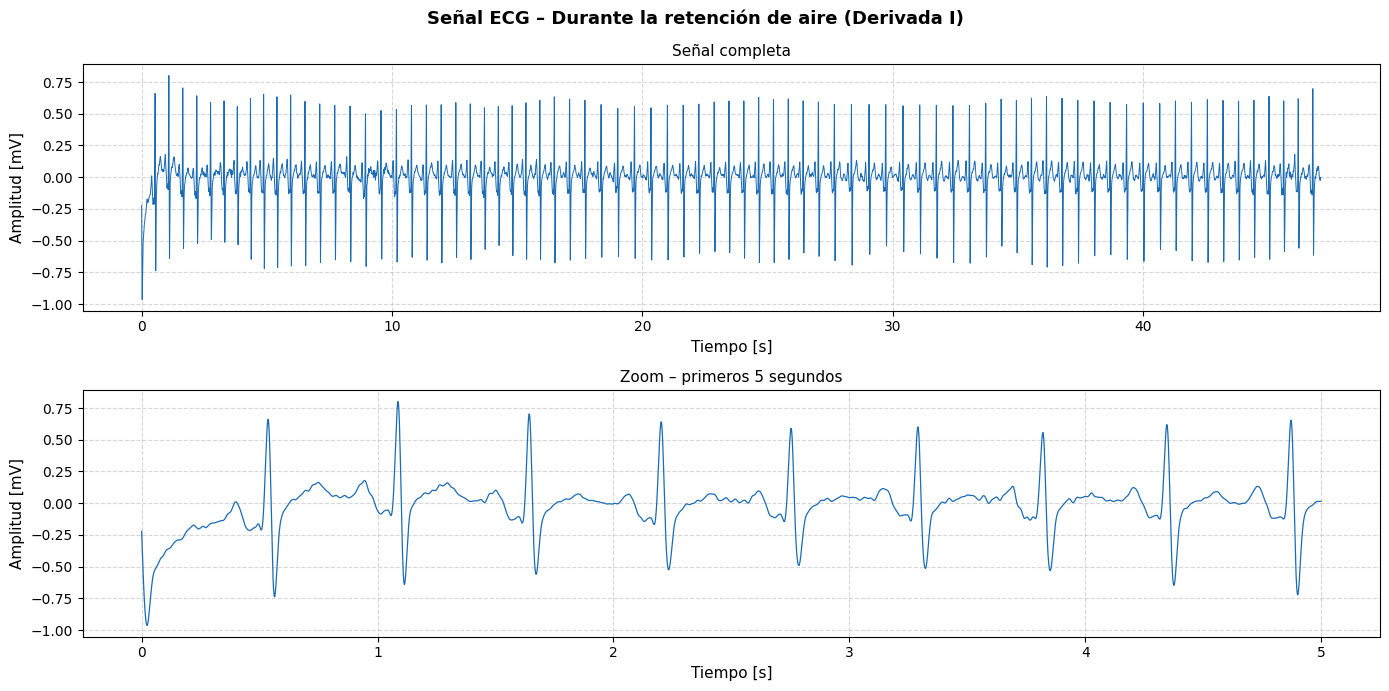

In [50]:
# ── Lectura ───────────────────────────────────────────────────────────────────
acq = OpenSignalsReader('actividad2_derivada1.txt')
fs  = acq.sampling_rate

ecg = acq.signal()['ECG'].astype(float)
ecg -= ecg.mean()

t = np.arange(len(ecg)) / fs

# ── Filtros ───────────────────────────────────────────────────────────────────
def bandpass(sig, low, high, fs, order=4):
    b, a = butter(order, [low/(0.5*fs), high/(0.5*fs)], btype='band')
    return filtfilt(b, a, sig)

ecg = bandpass(ecg, 0.5, 40, fs)
b_n, a_n = iirnotch(60, 30, fs)
ecg = filtfilt(b_n, a_n, ecg)

# ── Detección de picos R y FC ─────────────────────────────────────────────────
peaks, _ = find_peaks(ecg, distance=int(0.4*fs), height=0.4*ecg.max())
rr_ms    = np.diff(peaks) / fs * 1000
fc_media = (60 / (rr_ms / 1000)).mean()

print(f"Frecuencia cardíaca media: {fc_media:.1f} bpm")

# ── Graficar señal completa ───────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 7))
fig.suptitle("Señal ECG – Durante la retención de aire (Derivada I)", fontsize=13, fontweight='bold')

# Señal completa
ax1.plot(t, ecg, color='#1a6bb5', lw=0.7)
ax1.set_title("Señal completa", fontsize=11)
ax1.set_xlabel("Tiempo [s]", fontsize=11)
ax1.set_ylabel("Amplitud [mV]", fontsize=11)
ax1.grid(True, linestyle='--', alpha=0.5)

# Zoom 5 segundos
samples = 5 * fs
ax2.plot(t[:samples], ecg[:samples], color='#1a6bb5', lw=0.9)
ax2.set_title("Zoom – primeros 5 segundos", fontsize=11)
ax2.set_xlabel("Tiempo [s]", fontsize=11)
ax2.set_ylabel("Amplitud [mV]", fontsize=11)
ax2.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()


Frecuencia cardíaca media: 99.1 bpm


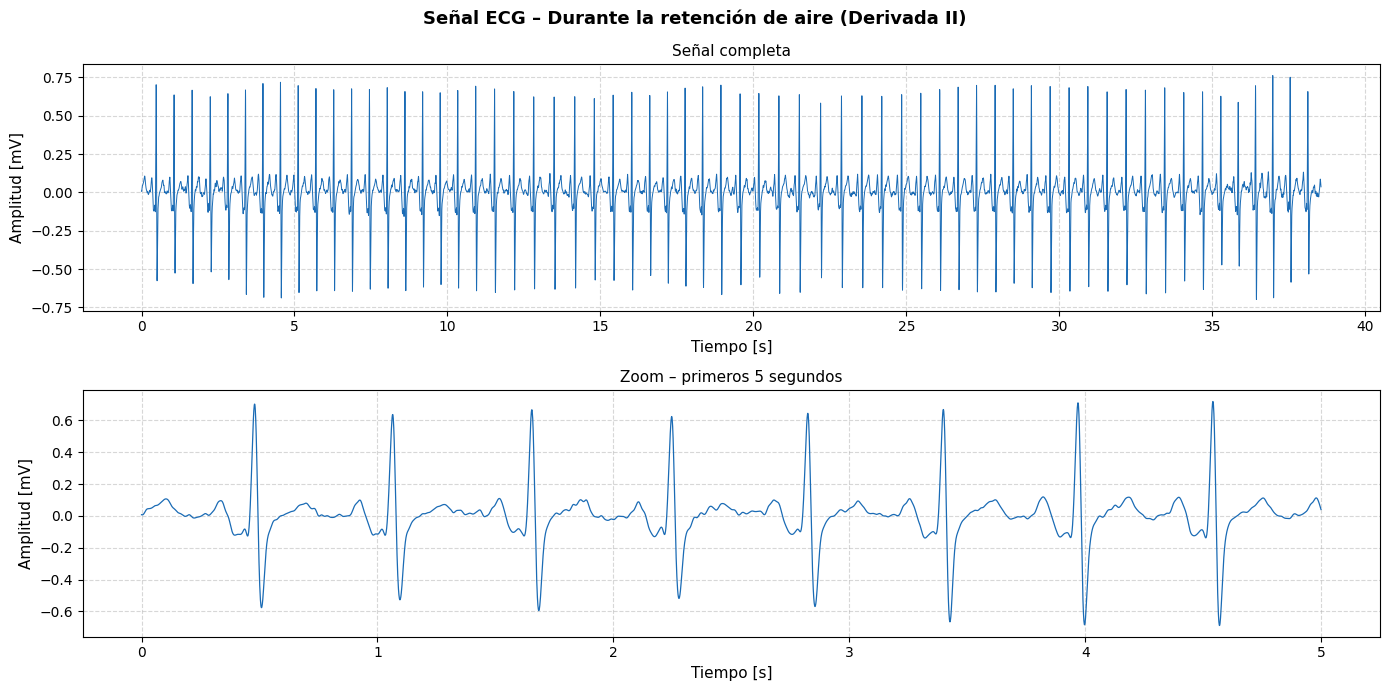

In [52]:
# ── Lectura ───────────────────────────────────────────────────────────────────
acq = OpenSignalsReader('actividad2_derivada2.txt')
fs  = acq.sampling_rate

ecg = acq.signal()['ECG'].astype(float)
ecg -= ecg.mean()

t = np.arange(len(ecg)) / fs

# ── Filtros ───────────────────────────────────────────────────────────────────
def bandpass(sig, low, high, fs, order=4):
    b, a = butter(order, [low/(0.5*fs), high/(0.5*fs)], btype='band')
    return filtfilt(b, a, sig)

ecg = bandpass(ecg, 0.5, 40, fs)
b_n, a_n = iirnotch(60, 30, fs)
ecg = filtfilt(b_n, a_n, ecg)

# ── Detección de picos R y FC ─────────────────────────────────────────────────
peaks, _ = find_peaks(ecg, distance=int(0.4*fs), height=0.4*ecg.max())
rr_ms    = np.diff(peaks) / fs * 1000
fc_media = (60 / (rr_ms / 1000)).mean()

print(f"Frecuencia cardíaca media: {fc_media:.1f} bpm")

# ── Graficar señal completa ───────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 7))
fig.suptitle("Señal ECG – Durante la retención de aire (Derivada II)", fontsize=13, fontweight='bold')

# Señal completa
ax1.plot(t, ecg, color='#1a6bb5', lw=0.7)
ax1.set_title("Señal completa", fontsize=11)
ax1.set_xlabel("Tiempo [s]", fontsize=11)
ax1.set_ylabel("Amplitud [mV]", fontsize=11)
ax1.grid(True, linestyle='--', alpha=0.5)

# Zoom 5 segundos
samples = 5 * fs
ax2.plot(t[:samples], ecg[:samples], color='#1a6bb5', lw=0.9)
ax2.set_title("Zoom – primeros 5 segundos", fontsize=11)
ax2.set_xlabel("Tiempo [s]", fontsize=11)
ax2.set_ylabel("Amplitud [mV]", fontsize=11)
ax2.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

Frecuencia cardíaca media: 94.0 bpm


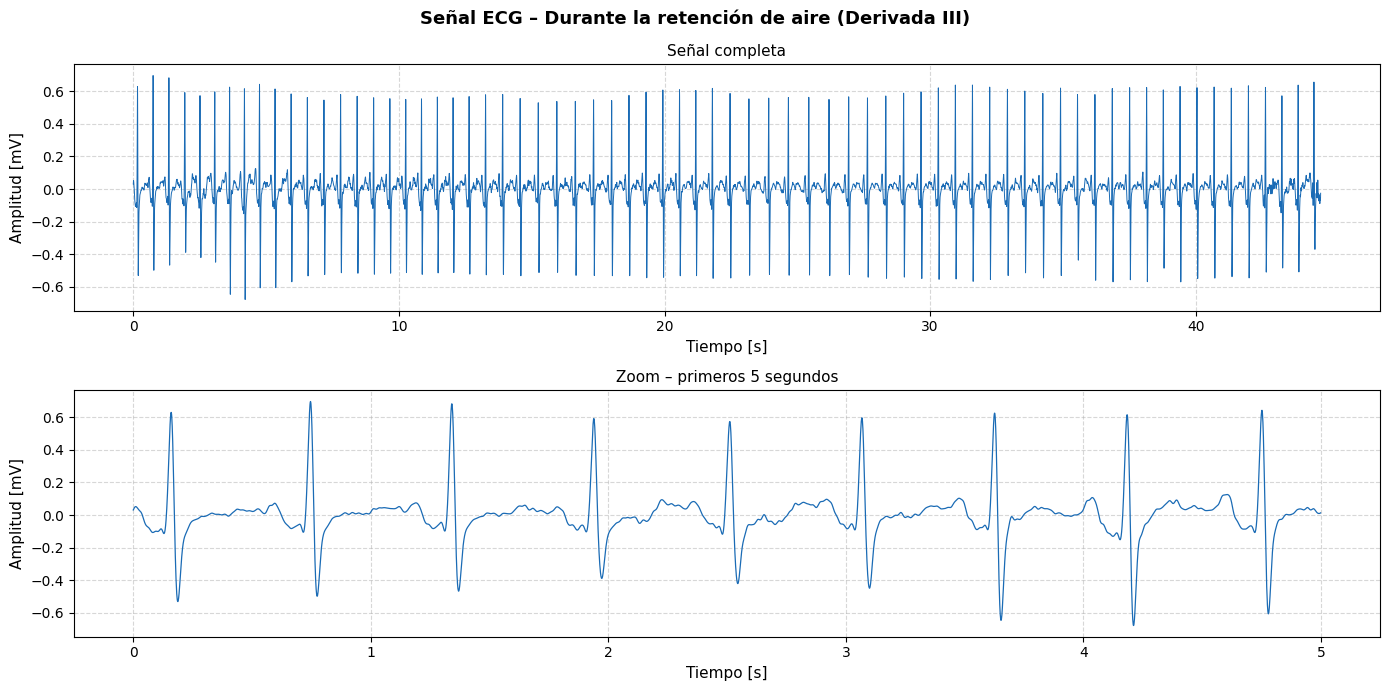

In [53]:
# ── Lectura ───────────────────────────────────────────────────────────────────
acq = OpenSignalsReader('a2derivada3.txt')
fs  = acq.sampling_rate

ecg = acq.signal()['ECG'].astype(float)
ecg -= ecg.mean()

t = np.arange(len(ecg)) / fs

# ── Filtros ───────────────────────────────────────────────────────────────────
def bandpass(sig, low, high, fs, order=4):
    b, a = butter(order, [low/(0.5*fs), high/(0.5*fs)], btype='band')
    return filtfilt(b, a, sig)

ecg = bandpass(ecg, 0.5, 40, fs)
b_n, a_n = iirnotch(60, 30, fs)
ecg = filtfilt(b_n, a_n, ecg)

# ── Detección de picos R y FC ─────────────────────────────────────────────────
peaks, _ = find_peaks(ecg, distance=int(0.4*fs), height=0.4*ecg.max())
rr_ms    = np.diff(peaks) / fs * 1000
fc_media = (60 / (rr_ms / 1000)).mean()

print(f"Frecuencia cardíaca media: {fc_media:.1f} bpm")

# ── Graficar señal completa ───────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 7))
fig.suptitle("Señal ECG – Durante la retención de aire (Derivada III)", fontsize=13, fontweight='bold')

# Señal completa
ax1.plot(t, ecg, color='#1a6bb5', lw=0.7)
ax1.set_title("Señal completa", fontsize=11)
ax1.set_xlabel("Tiempo [s]", fontsize=11)
ax1.set_ylabel("Amplitud [mV]", fontsize=11)
ax1.grid(True, linestyle='--', alpha=0.5)

# Zoom 5 segundos
samples = 5 * fs
ax2.plot(t[:samples], ecg[:samples], color='#1a6bb5', lw=0.9)
ax2.set_title("Zoom – primeros 5 segundos", fontsize=11)
ax2.set_xlabel("Tiempo [s]", fontsize=11)
ax2.set_ylabel("Amplitud [mV]", fontsize=11)
ax2.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()